# UdaciSense: Optimized Object Recognition

## Notebook 4: Mobile Deployment

In this notebook, you'll prepare your optimized model for mobile deployment.
You'll explore how to convert your best optimized model to a cross-platform mobile-friendly format,
and evaluate the performance that UdaciSense mobile users can expect.

In [4]:
# Make sure that libraries are dynamically re-loaded if changed
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import sys
from pathlib import Path

# Resolve the absolute path of the *project root* inside project-showroom
# Adjust `project_showroom_root` to your layout if needed
project_showroom_root = Path.cwd().resolve()

# Add the udasense project root to Python path
udasense_root = project_showroom_root # / "./"  # or whatever the folder is called
sys.path.insert(0, str(udasense_root))

print("Added to PYTHONPATH:", udasense_root)

# Set current working directory to udasense project root
%cd {udasense_root}
print("Current working directory:", Path.cwd())

Added to PYTHONPATH: /home/oliver/project-showroom/projects/model-opt/udaci-sense
/home/oliver/project-showroom/projects/model-opt/udaci-sense
Current working directory: /home/oliver/project-showroom/projects/model-opt/udaci-sense


In [6]:
# Import necessary libraries
import copy
import os
import json
import time
import numpy as np
import pandas as pd
import pprint
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.quantization
from typing import Dict, Any, List, Tuple, Optional, Union, Callable
import warnings

from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import (
    plot_model_comparison, plot_multiple_models_comparison, 
    create_model_summary_dashboard
)
from utils.compression import is_quantized
from utils.evaluation import evaluate_model_metrics, compare_models

In [7]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings

### Step 1: Set up the Environment

In [8]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

Devices available: ['cpu', 'cuda:0 (NVIDIA GeForce RTX 4070 Laptop GPU)']


In [5]:
# Setup directories
os.makedirs("./models/mobile", exist_ok=True)
os.makedirs("./results/mobile", exist_ok=True)

In [9]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Extracting household classes from CIFAR100 for test set...
Input has size: (1, 3, 32, 32)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


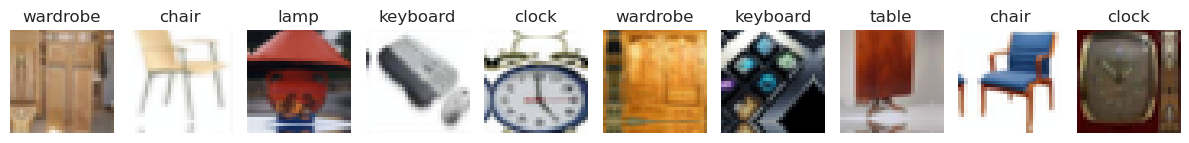


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


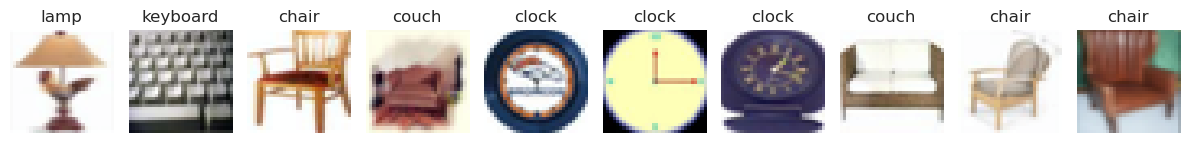

In [ ]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=4,
)

# Get input_size
input_size = get_input_size("CIFAR")
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3. Load the optimized model and metrics

In [11]:
experiment_name = "p1_pqt_dynamic_torchscript"
optimized_model_path = f"./models/pipeline/{experiment_name}/model.pt"

In [12]:
# Load the optimized model
optimized_model = load_model(optimized_model_path)
print_model_summary(optimized_model)

# Load optimized model metrics
with open(f"./results/pipeline/{experiment_name}/pipeline_metrics.json", "r") as f:
    optimized_metrics = json.load(f)

print("\nOptimized Model Metrics:")
pprint.pp(optimized_metrics)

Model Architecture:
RecursiveScriptModule(
  original_name=MobileNetV3_Household
  (model): RecursiveScriptModule(
    original_name=MobileNetV3
    (features): RecursiveScriptModule(
      original_name=Sequential
      (0): RecursiveScriptModule(
        original_name=Conv2dNormActivation
        (0): RecursiveScriptModule(original_name=Conv2d)
        (1): RecursiveScriptModule(original_name=BatchNorm2d)
        (2): RecursiveScriptModule(original_name=Hardswish)
      )
      (1): RecursiveScriptModule(
        original_name=InvertedResidual
        (block): RecursiveScriptModule(
          original_name=Sequential
          (0): RecursiveScriptModule(
            original_name=Conv2dNormActivation
            (0): RecursiveScriptModule(original_name=Conv2d)
            (1): RecursiveScriptModule(original_name=BatchNorm2d)
            (2): RecursiveScriptModule(original_name=ReLU)
          )
          (1): RecursiveScriptModule(
            original_name=SqueezeExcitation
        

### Step 4. Convert optimized model for mobile

In [ ]:
import os
import torch
import torch.nn as nn
from typing import Tuple, Dict, Any


def convert_model_for_mobile(
    ts_model: nn.Module,
    input_size: Tuple[int, ...] = (1, 3, 32, 32),
    mobile_optimize: bool = True,
    out_dir: str = "./models/mobile",
    base_name: str = "optimized_model_mobile",
) -> Dict[str, Any]:
    """
    Convert a (TorchScript) model into a deployable artifact and optionally apply
    runtime-only inference optimizations.

    In PyTorch 2.9, torch.jit.optimize_for_inference() is NOT guaranteed to be serializable.
    Therefore:
      - We save the deployable (serializable) TorchScript module.
      - We optionally return a runtime-optimized module for benchmarking and output checks.

    And very important: optimize for mobile functionality was removed in PyTorch 2.0+,
    so we do NOT apply it here.

    Args:
        ts_model: A TorchScript module (or nn.Module, but expected to be TorchScript here)
        input_size: Input size for potential checks (kept for compatibility with notebook)
        mobile_optimize: If True, applies torch.jit.optimize_for_inference() runtime-only
        out_dir: Output directory for saved artifacts
        base_name: Base name for saved files

    Returns:
        dict with:
          - deployable_model: serializable model to save
          - runtime_optimized_model: optimized-for-inference model (do not save), optional
          - torchscript_path: path to saved .pt
          - lite_saved: whether .ptl was produced
          - lite_path: path to .ptl if produced
    """
    os.makedirs(out_dir, exist_ok=True)

    # Always eval for export/deploy
    ts_model.eval()

    # Prefer a "deployable" model that is still serializable.
    # Freeze often makes deployment artifacts more stable and smaller.
    try:
        deployable = torch.jit.freeze(ts_model)  # works only for TorchScript modules
    except Exception:
        # If freeze fails (or ts_model is not TorchScript), fall back
        deployable = ts_model

    # Save serializable TorchScript artifact
    pt_path = os.path.join(out_dir, f"{base_name}.pt")
    torch.jit.save(deployable, pt_path)

    # Optional: save Lite Interpreter artifact (if supported by this build)
    ptl_path = os.path.join(out_dir, f"{base_name}.ptl")
    lite_saved = False
    if hasattr(deployable, "_save_for_lite_interpreter"):
        try:
            deployable._save_for_lite_interpreter(ptl_path)
            lite_saved = True
        except Exception:
            lite_saved = False

    runtime_optimized = None
    if mobile_optimize:
        # Runtime-only optimization: do NOT save this, not guaranteed serializable
        runtime_optimized = torch.jit.optimize_for_inference(deployable)

    return {
        "deployable_model": deployable,
        "runtime_optimized_model": runtime_optimized,
        "torchscript_path": pt_path,
        "lite_saved": lite_saved,
        "lite_path": ptl_path if lite_saved else None,
    }

In [ ]:
# Convert the model for mobile deployment
print("\nConverting model for mobile deployment...")

conversion = convert_model_for_mobile(
    optimized_model,
    input_size=input_size,
    mobile_optimize=True,   # runtime-only inference optimization
)

# Decide what you call "mobile_model" in the notebook:
# We save the DEPLOYABLE model, because it is serializable.
mobile_model = conversion["deployable_model"]

# Save the mobile model (deployable TorchScript)
mobile_model_path = conversion["torchscript_path"]
print(f"Saved mobile-compatible model to: {mobile_model_path}")

# Optional info about lite interpreter artifact
if conversion["lite_saved"]:
    print(f"Also saved Lite Interpreter model to: {conversion['lite_path']}")
else:
    print("Lite Interpreter saving not available in this PyTorch build (or saving failed).")

runtime_optimized_model = conversion["runtime_optimized_model"]


Converting model for mobile deployment...
Saved mobile-compatible model to: ./models/mobile/optimized_model_mobile.pt
Also saved Lite Interpreter model to: ./models/mobile/optimized_model_mobile.ptl


### Step 5: Verify Mobile Model Performance

Before packaging for deployment, let's verify that your optimized model meets the requirements.

#### Model output consistency

In [18]:
import torch
import torch.nn as nn

def compare_model_outputs(
    model1: nn.Module,
    model2: nn.Module,
    input_tensor: torch.Tensor,
    atol: float = 1e-4,
    rtol: float = 1e-4,
) -> bool:
    """
    Compare outputs of two models to verify consistency after conversion.

    Works with:
      - eager nn.Module
      - TorchScript modules

    Returns True if outputs are numerically close.

    Notes:
      - Uses eval + no_grad
      - Moves models and input to a common device (prefers model1's device)
    """
    model1.eval()
    model2.eval()

    # pick a common device
    def _first_param_device(m: nn.Module) -> torch.device:
        for p in m.parameters():
            return p.device
        for b in m.buffers():
            return b.device
        return torch.device("cpu")

    device = _first_param_device(model1)

    # Move input to device. If model2 lives elsewhere, try to align it too.
    x = input_tensor.to(device)

    try:
        model2 = model2.to(device)  # works for eager modules; TorchScript usually supports .to
    except Exception:
        pass

    with torch.no_grad():
        y1 = model1(x)
        y2 = model2(x)

    # Handle tuple/list outputs (some models return multiple values)
    def _to_flat_tensor(y):
        if isinstance(y, (tuple, list)):
            # concatenate all tensor outputs
            tensors = [t.reshape(-1) for t in y if torch.is_tensor(t)]
            if not tensors:
                raise TypeError("Model output tuple/list contains no tensors.")
            return torch.cat(tensors)
        if torch.is_tensor(y):
            return y.reshape(-1)
        raise TypeError(f"Unsupported model output type: {type(y)}")

    t1 = _to_flat_tensor(y1).detach().cpu()
    t2 = _to_flat_tensor(y2).detach().cpu()

    if t1.shape != t2.shape:
        return False

    return torch.allclose(t1, t2, atol=atol, rtol=rtol)

dummy_input = torch.randn(input_size)
output_consistency = compare_model_outputs(optimized_model, mobile_model, dummy_input)
print(f"Output consistency check (optimized vs deployable): {'PASSED' if output_consistency else 'FAILED'}")


Output consistency check (optimized vs deployable): PASSED


In [ ]:
dummy_input = torch.randn(input_size)

runtime_optimized_model = conversion["runtime_optimized_model"]
if runtime_optimized_model is None:
    print("Runtime optimized model not available (mobile_optimize=False).")
else:
    output_consistency_rt = compare_model_outputs(mobile_model, runtime_optimized_model, dummy_input)
    print(f"Output consistency check (deployable vs runtime-optimized): {'PASSED' if output_consistency_rt else 'FAILED'}")

Output consistency check (deployable vs runtime-optimized): PASSED


#### Model size

In [24]:
import os
from typing import Union


def get_model_size(path: Union[str, os.PathLike], unit: str = "MB") -> float:
    """
    Get the on-disk size of a saved model artifact.

    This is the correct metric for deployment, since it reflects what is
    actually shipped to a device.

    Args:
        path: Path to model file (.pt, .ptl, etc.)
        unit: "B", "KB", or "MB"

    Returns:
        File size in requested unit.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model file not found: {path}")

    size_bytes = os.path.getsize(path)

    unit = unit.upper()
    if unit == "B":
        return float(size_bytes)
    elif unit == "KB":
        return size_bytes / 1024.0
    elif unit == "MB":
        return size_bytes / (1024.0 ** 2)
    else:
        raise ValueError(f"Unsupported unit '{unit}'. Use 'B', 'KB', or 'MB'.")

pth_size_mb = get_model_size("./models/baseline_mobilenet/checkpoints/model.pth", unit="MB")
print(f"Baseline checkpoint size: {pth_size_mb:.2f} MB")

# Report model sizes
pt_size_mb = get_model_size(mobile_model_path, unit="MB")
print(f"Deployable TorchScript model size: {pt_size_mb:.2f} MB")

if conversion["lite_saved"]:
    ptl_size_mb = get_model_size(conversion["lite_path"], unit="MB")
    print(f"Lite Interpreter model size: {ptl_size_mb:.2f} MB")

# optimized_size = get_model_size(optimized_model_path)
# mobile_size = get_model_size(mobile_model_path)

# print(f"Original model size: {optimized_size:.2f} MB")
# print(f"Mobile model size: {mobile_size:.2f} MB")
# print(f"\nSize change from optimized to mobile: {(mobile_size - optimized_size) / optimized_size * 100:.2f}%")

Baseline checkpoint size: 5.95 MB
Deployable TorchScript model size: 4.13 MB
Lite Interpreter model size: 4.71 MB


> Load also baseline model:

In [26]:
# Load the baseline model
from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP, TARGET_MODEL_COMPRESSION


baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"./models/{baseline_model_name}/checkpoints/model.pth"))
print_model_summary(baseline_model)

# Load baseline metrics
with open(f"./results/{baseline_model_name}/metrics.json", "r") as f:
    baseline_metrics = json.load(f)

print("\nBaseline Model Metrics:")
pprint.pp(baseline_metrics)

# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

#### Evaluate models on test set


Evaluating DEPLOYABLE TorchScript model (frozen, serializable)...

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  6.18it/s]


Baseline metrics saved at ./results/torchscript_frozen/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:01<00:00,  5.94it/s]


Confusion matrix saved to ./results/torchscript_frozen/confusion_matrix.png


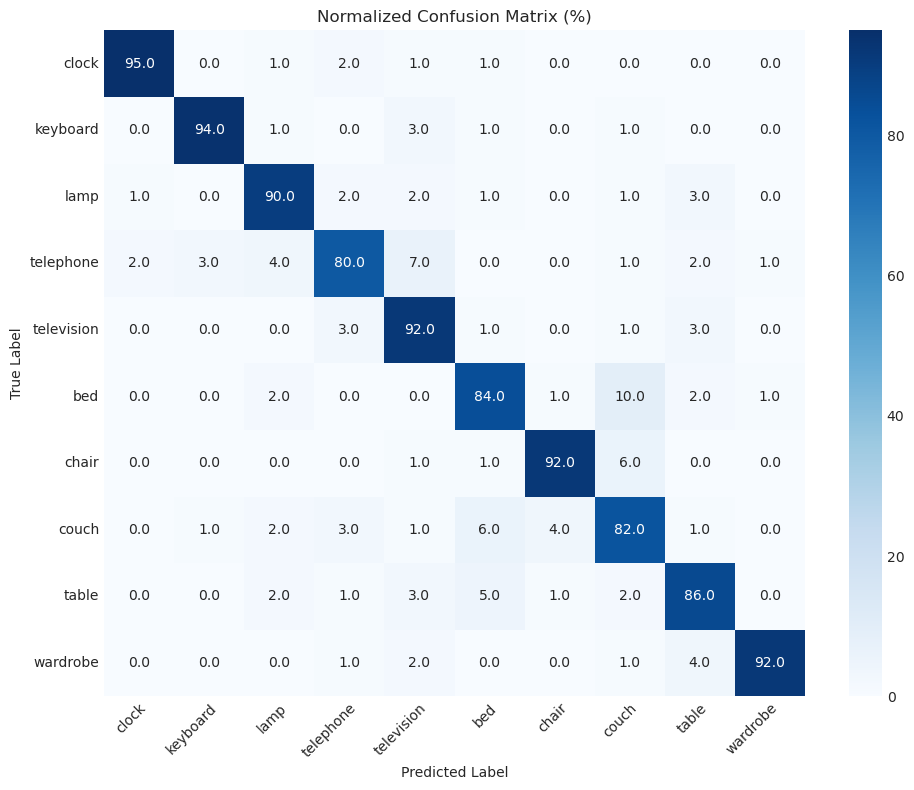


Optimized Model Metrics (torchscript_frozen):
Accuracy: 88.70%
Model Size: 0.59 MB
CPU Inference Time: 10.90 ms (91.73 FPS)

Comparing DEPLOYABLE TorchScript model to baseline...

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.94it/s]


Model comparison plot saved to ./results/torchscript_frozen/comparison.png


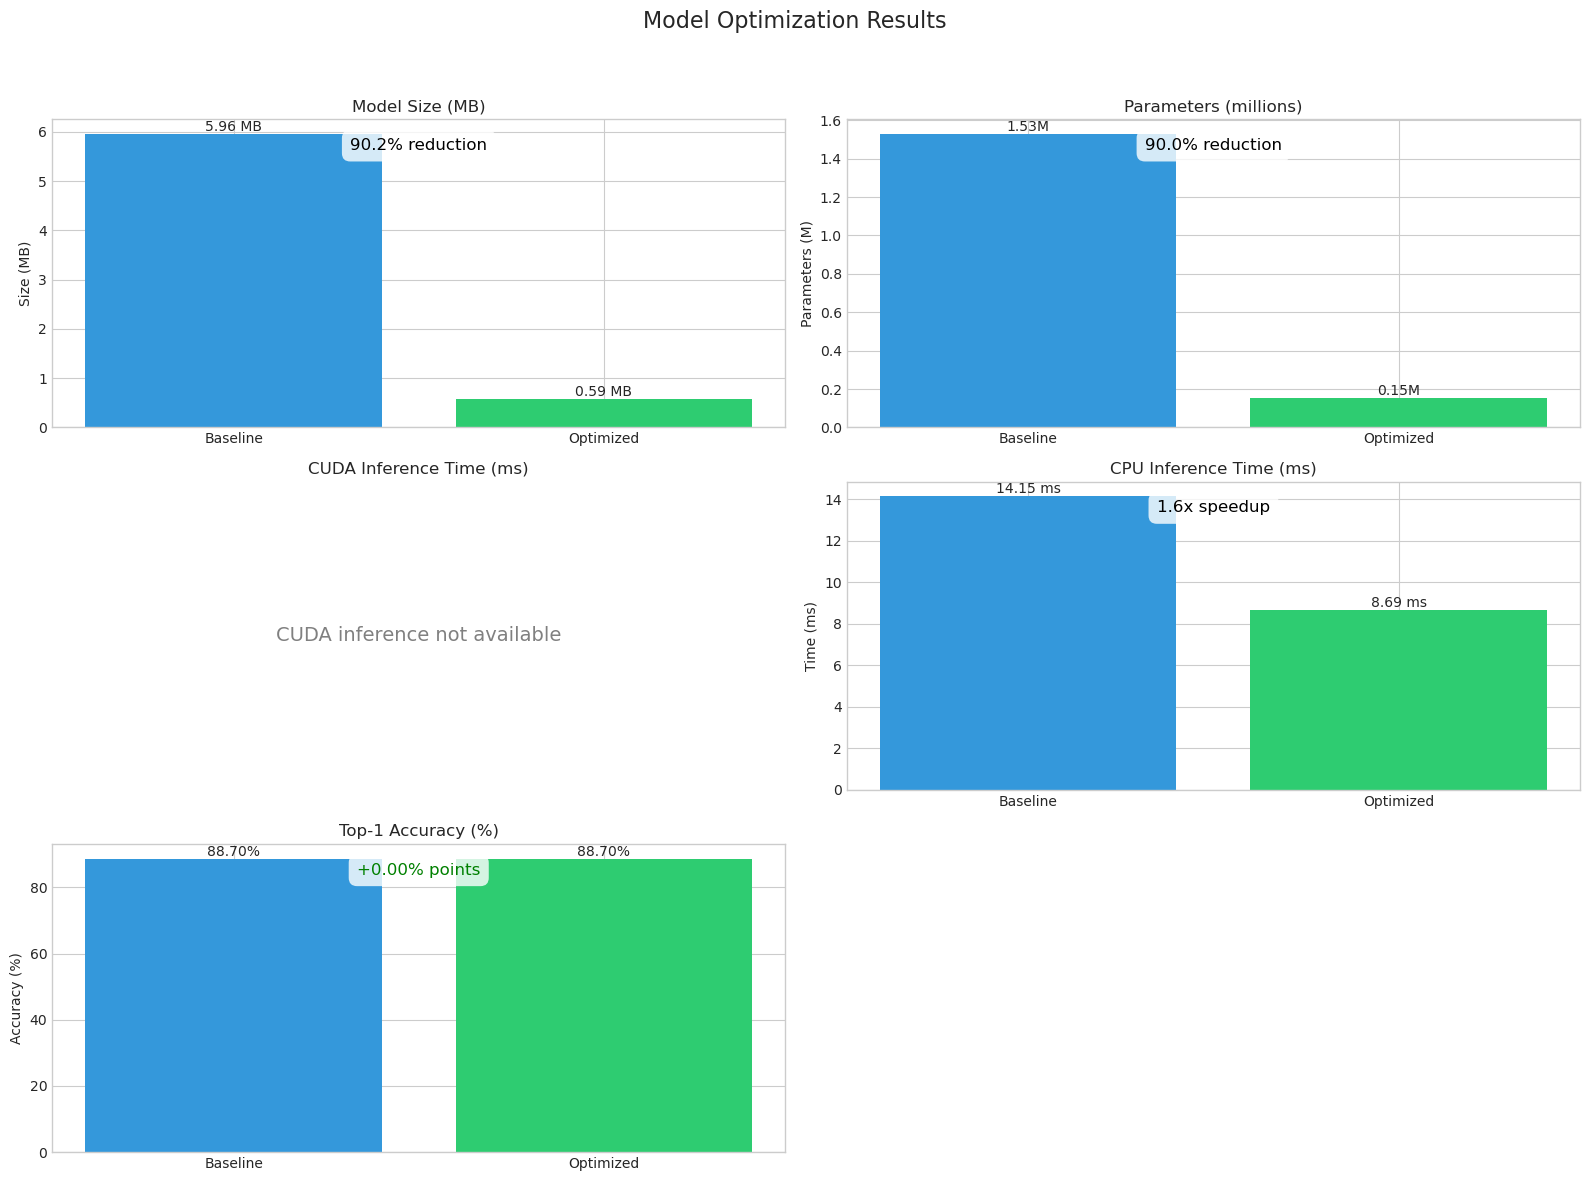


torchscript_frozen Results:
Model Size: 0.59 MB (90.2% reduction)
Parameters: 153,493 (90.0% reduction)
CPU Inference Time: 8.69 ms (1.6x speedup)
Accuracy: 88.70% (+0.00% change)
Requirements met: False

Evaluating RUNTIME-OPTIMIZED model (optimize_for_inference, not serializable)...

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  5.97it/s]


Baseline metrics saved at ./results/torchscript_optimize_for_inference/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:01<00:00,  5.00it/s]


Confusion matrix saved to ./results/torchscript_optimize_for_inference/confusion_matrix.png


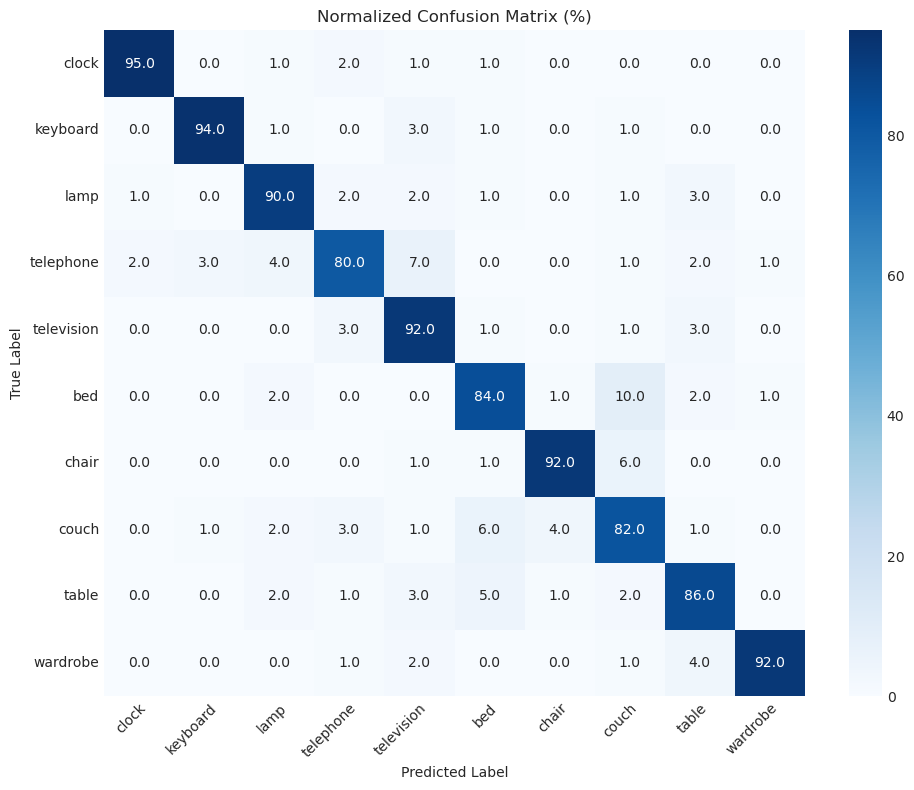


Optimized Model Metrics (torchscript_optimize_for_inference):
Accuracy: 88.70%
Model Size: 0.59 MB
CPU Inference Time: 11.44 ms (87.39 FPS)

Comparing RUNTIME-OPTIMIZED model to baseline...

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:03<00:00,  2.45it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  4.40it/s]


Model comparison plot saved to ./results/torchscript_optimize_for_inference/comparison.png


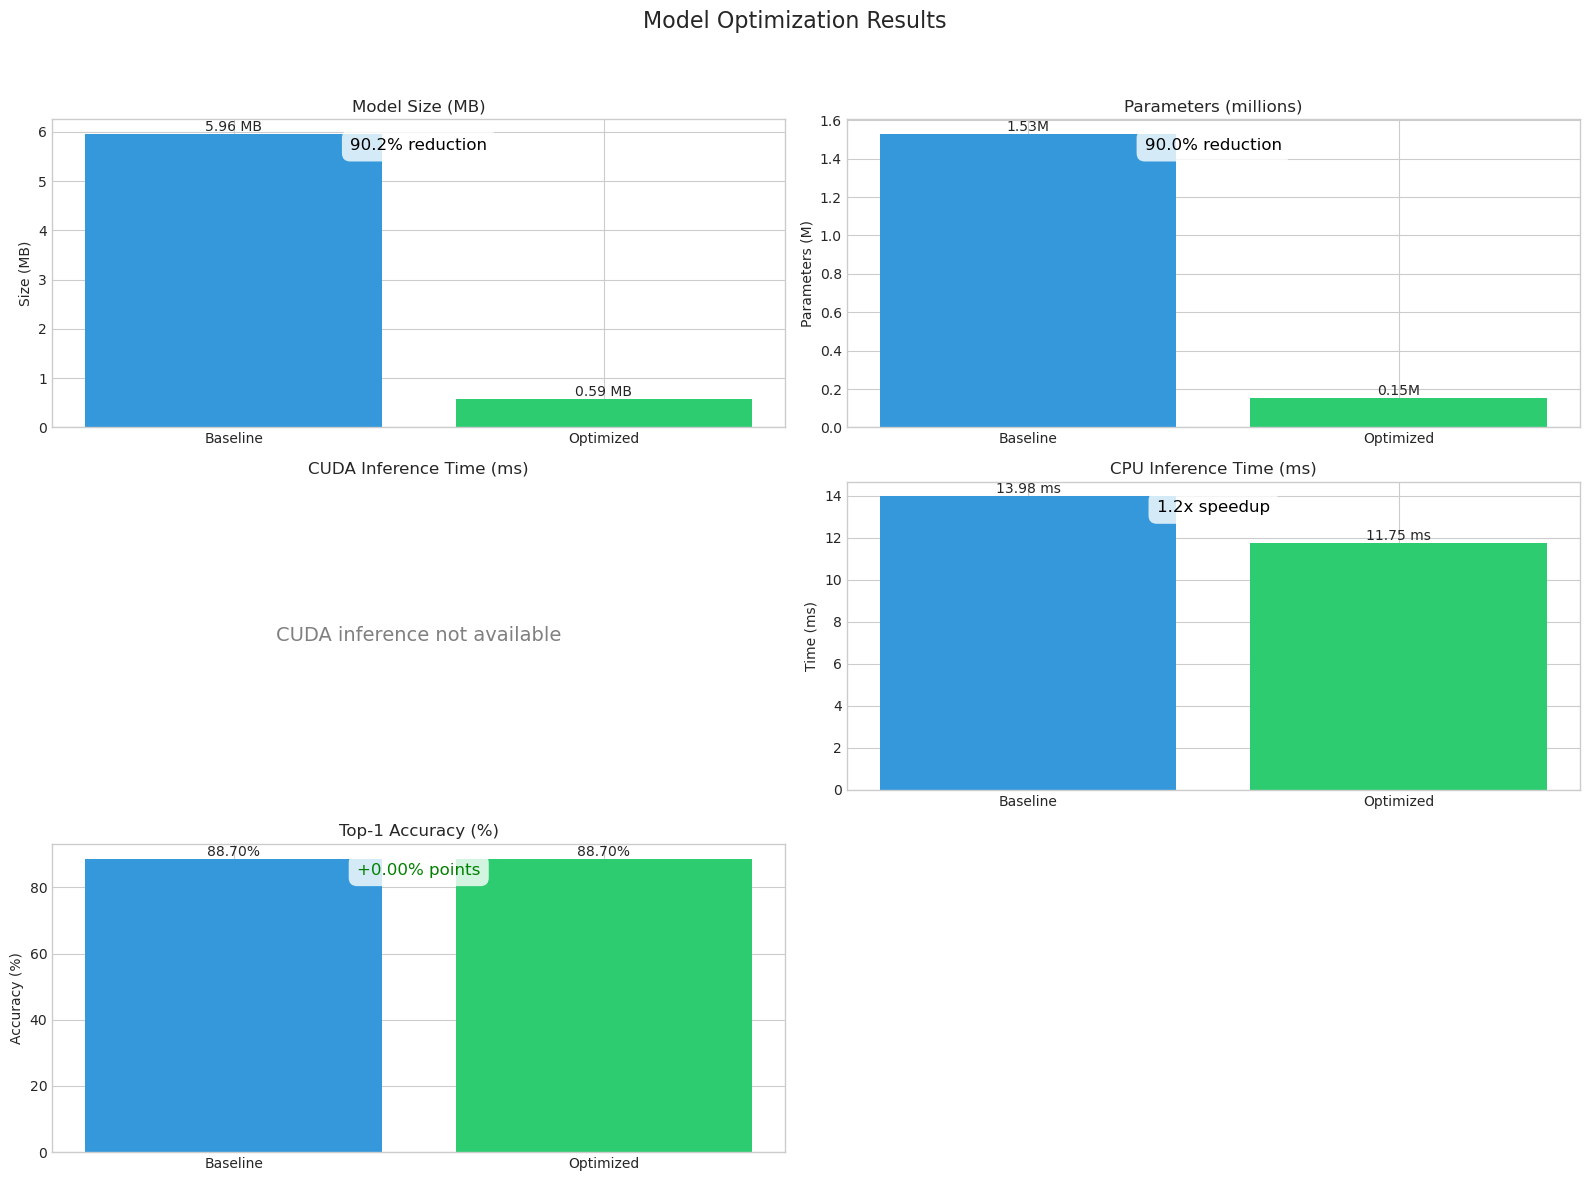


torchscript_optimize_for_inference Results:
Model Size: 0.59 MB (90.2% reduction)
Parameters: 153,493 (90.0% reduction)
CPU Inference Time: 11.75 ms (1.2x speedup)
Accuracy: 88.70% (+0.00% change)
Requirements met: False

--- Summary: Deployable vs Runtime-Optimized ---
Deployable accuracy: {'top1_acc': 88.7, 'top5_acc': 99.1}
Runtime-optimized accuracy: {'top1_acc': 88.7, 'top5_acc': 99.1}

Saved deployment evaluation results to ./results/deployment/deployment_eval_results.json


In [30]:
# ------------------------------------------------------------
# Evaluate deployable (serializable) vs runtime-optimized model
# ------------------------------------------------------------

from utils.compression import compare_optimized_model_to_baseline, evaluate_optimized_model


device_for_eval = torch.device("cpu")  # keep it explicit, TorchScript CPU path is your winner

deployable_model = conversion["deployable_model"]
runtime_model = conversion["runtime_optimized_model"]

# Sanity checks
deployable_model.eval()
if runtime_model is not None:
    runtime_model.eval()

results_04 = {}

print("\nEvaluating DEPLOYABLE TorchScript model (frozen, serializable)...")
deployable_metrics, deployable_cm = evaluate_optimized_model(
    deployable_model,
    test_loader,
    technique_name="torchscript_frozen",
    class_names=class_names,
    input_size=input_size,
    device=device_for_eval,
)
results_04["deployable"] = {
    "metrics": deployable_metrics,
    "confusion_matrix": deployable_cm,
}

print("\nComparing DEPLOYABLE TorchScript model to baseline...")
deployable_vs_baseline = compare_optimized_model_to_baseline(
    baseline_model,
    deployable_model,
    technique_name="torchscript_frozen",
    data_loader=test_loader,
    class_names=class_names,
    device=device_for_eval,
)
results_04["deployable"]["comparison_to_baseline"] = deployable_vs_baseline


if runtime_model is None:
    print("\nRuntime optimized model not available (mobile_optimize=False). Skipping runtime evaluation.")
else:
    print("\nEvaluating RUNTIME-OPTIMIZED model (optimize_for_inference, not serializable)...")
    runtime_metrics, runtime_cm = evaluate_optimized_model(
        runtime_model,
        test_loader,
        technique_name="torchscript_optimize_for_inference",
        class_names=class_names,
        input_size=input_size,
        device=device_for_eval,
    )
    results_04["runtime_optimized"] = {
        "metrics": runtime_metrics,
        "confusion_matrix": runtime_cm,
    }

    print("\nComparing RUNTIME-OPTIMIZED model to baseline...")
    runtime_vs_baseline = compare_optimized_model_to_baseline(
        baseline_model,
        runtime_model,
        technique_name="torchscript_optimize_for_inference",
        data_loader=test_loader,
        class_names=class_names,
        device=device_for_eval,
    )
    results_04["runtime_optimized"]["comparison_to_baseline"] = runtime_vs_baseline


# ------------------------------------------------------------
# Direct comparison: deployable vs runtime-optimized metrics
# ------------------------------------------------------------
def _safe_get(d: dict, *keys, default=None):
    cur = d
    for k in keys:
        if cur is None or k not in cur:
            return default
        cur = cur[k]
    return cur

print("\n--- Summary: Deployable vs Runtime-Optimized ---")
deploy_acc = _safe_get(results_04, "deployable", "metrics", "accuracy")
run_acc = _safe_get(results_04, "runtime_optimized", "metrics", "accuracy")

print(f"Deployable accuracy: {deploy_acc}")
print(f"Runtime-optimized accuracy: {run_acc}")

deploy_time = _safe_get(results_04, "deployable", "metrics", "inference_time_ms")
run_time = _safe_get(results_04, "runtime_optimized", "metrics", "inference_time_ms")

if deploy_time is not None and run_time is not None:
    print(f"Deployable inference time (ms): {deploy_time}")
    print(f"Runtime-optimized inference time (ms): {run_time}")
    try:
        speedup = deploy_time / run_time
        print(f"Speedup from optimize_for_inference: {speedup:.2f}x")
    except Exception:
        pass


# ------------------------------------------------------------
# Optional: persist results for later reference
# ------------------------------------------------------------
import json
os.makedirs("./results/deployment", exist_ok=True)
with open("./results/deployment/deployment_eval_results.json", "w") as f:
    # confusion matrices might be numpy arrays; make them serializable if needed
    def _to_jsonable(x):
        try:
            import numpy as np
            if isinstance(x, np.ndarray):
                return x.tolist()
        except Exception:
            pass
        return x

    json.dump(
        {
            "deployable": {
                "metrics": results_04["deployable"]["metrics"],
                "comparison_to_baseline": results_04["deployable"]["comparison_to_baseline"],
                "confusion_matrix": _to_jsonable(results_04["deployable"]["confusion_matrix"]),
            },
            "runtime_optimized": None if "runtime_optimized" not in results_04 else {
                "metrics": results_04["runtime_optimized"]["metrics"],
                "comparison_to_baseline": results_04["runtime_optimized"]["comparison_to_baseline"],
                "confusion_matrix": _to_jsonable(results_04["runtime_optimized"]["confusion_matrix"]),
            }
        },
        f,
        indent=2
    )

print("\nSaved deployment evaluation results to ./results/deployment/deployment_eval_results.json")


#### Benchmark Mobile Performance

In this section, you should develop a strategy for benchmarking the model on actual mobile 
hardware. Since we can't easily test on ARM mobile devices in this environment, describe:

1. What tools and frameworks you would use for mobile benchmarking?
2. What specific metrics you would collect?
3. How you would set up a fair comparison between models?
4. What mobile-specific factors you would control for in your tests?

Write your benchmarking approach in the final report directly.

## Benchmark Mobile Performance

A meaningful mobile benchmark must measure inference performance on real ARM devices under controlled conditions. Desktop CPU timing, especially on a fast i9-class processor, does not translate well to mobile because the bottlenecks and runtime behavior differ substantially. The goal is therefore to define a reproducible on-device benchmarking workflow that can be applied consistently across candidate models.

### 1) Tools and frameworks for mobile benchmarking

**Android (primary target)**

* **PyTorch Android / Lite Interpreter** (if using TorchScript `.ptl` artifacts): integrate the model into a minimal Android app and run repeated inference.
* **Android Studio Profiler**: inspect CPU utilization, memory allocations, and potential thermal throttling behavior during long runs.
* **Perfetto / Android system tracing**: system-level tracing for CPU scheduling, frequency scaling, and performance anomalies.
* **Jetpack Benchmark / Macrobenchmark**: automate repeatable benchmarks across runs with consistent app startup conditions and stable measurement.
* **Simple native timing using `System.nanoTime()`** inside the inference loop, combined with structured logging to file.

**iOS (secondary target)**

* **PyTorch iOS runtime** if staying with TorchScript artifacts.
* **Xcode Instruments** (Time Profiler, Allocations, Energy Log): profiling CPU, allocations, and energy consumption patterns.

**Optional, depending on deployment stack**

* If the production target is not PyTorch Mobile anymore, but a modern mobile runtime (for example ExecuTorch or a TFLite-compatible export), the equivalent would be:

  * runtime-specific benchmark harness (ExecuTorch runner, TFLite benchmark tool)
  * system profilers as above

The key point is: whichever runtime is used, benchmarking must be performed in the same runtime that will be used in production, not in Python.

### 2) Metrics to collect

At minimum, measure these on-device:

**Latency metrics**

* **p50 / p90 / p99 latency** per inference (single image)
* **cold start latency**: first inference after app start or model load
* **warm latency**: steady-state after warmup

**Throughput metrics**

* **images per second** for a fixed batch size (usually batch size 1 on mobile)
* optional: throughput under sustained load (for thermal behavior)

**Resource metrics**

* **Peak and steady-state memory usage** (RSS, heap allocations)
* **Model file size on disk** (what is actually shipped)
* **CPU utilization and thread count** during inference
* **Energy consumption proxy metrics**:

  * Android: power/energy via Battery Historian or OEM power metrics if available
  * iOS: Energy Log in Instruments
    These are rarely perfect but still useful for comparing models.

**Correctness**

* For a fixed evaluation subset: top-1 accuracy (or accuracy proxy) on-device to ensure no runtime-related deviations.
* Output consistency checks for a small deterministic test set.

### 3) Strategy for fair comparison between models

To compare models fairly, keep everything constant except the model artifact.

**Same test harness**

* Same app, same runtime, same device, same OS version.
* Only swap the model file and its loading path.

**Same input pipeline**

* Same preprocessing (resize, normalization, layout conversion).
* Ideally move preprocessing off the benchmark path or measure it separately, because preprocessing can dominate latency on mobile.

**Same warmup and run protocol**

* Fixed warmup count (for example 30 to 100 inferences).
* Fixed number of measured runs (for example 300 to 1000).
* Randomize input order but keep the same input set across models.

**Fixed threading and execution mode**

* Explicitly set the number of threads if the runtime allows it.
* Run in the same execution mode (no debug builds, no profiler attached unless measuring profiling overhead explicitly).

**Multiple runs and statistical reporting**

* Run each benchmark multiple times (for example 5 to 10 sessions) and report distributions, not single numbers.
* Report p50/p90/p99 rather than mean only, because mobile timing often has heavy tails.

### 4) Mobile-specific factors to control for

Mobile devices introduce several confounders that must be controlled or at least monitored:

**Thermal throttling**

* Sustained inference increases device temperature, which reduces CPU/GPU frequency.
* Mitigation: run benchmarks after a cool-down period, monitor temperature where possible, and report performance over time (first minute vs fifth minute).

**CPU frequency scaling and background load**

* Mobile OS aggressively changes CPU frequency based on load and battery state.
* Mitigation: airplane mode, disable battery saver, close background apps, keep screen brightness fixed, keep the device plugged in or run all tests on battery with a fixed battery range.

**Memory pressure and allocation patterns**

* Excess allocations during inference can trigger GC (Android) or paging, causing spikes.
* Mitigation: reuse input tensors, avoid repeated allocations inside the benchmark loop, measure allocations and peak memory.

**Thread scheduling differences**

* Big.LITTLE architectures schedule workloads across efficiency and performance cores.
* Mitigation: use fixed thread counts and keep conditions consistent; record device model and CPU topology.

**Hardware acceleration differences**

* If using GPU, NNAPI, or platform acceleration, results can vary dramatically by device and driver.
* Mitigation: either benchmark purely CPU across all models, or benchmark accelerator paths separately and clearly label them.

**Cold start behavior**

* Model load and first inference can matter more on mobile than steady-state.
* Mitigation: measure both cold and warm separately and document both.

---

### Practical benchmark plan for UdaciSense

A realistic approach for this project is:

1. Build a minimal Android benchmark app that loads the deployable TorchScript artifact (`.pt` or `.ptl`).
2. Implement a benchmark loop with warmup and repeated timed inference using a fixed set of sample images.
3. Log latency percentiles, throughput, memory usage, and model size.
4. Repeat for baseline and optimized models under identical conditions.
5. Report results as distributions and explicitly document thermal and power conditions during each run.

This produces a trustworthy performance picture on the actual target hardware and avoids overinterpreting desktop CPU timing that does not reflect mobile constraints.


--------

After converting your optimized model for mobile deployment, analyze how the model will perform in real-world mobile environments.

Consider these guiding questions:
- How did the mobile conversion affect the model's performance characteristics?
- What mobile-specific considerations impact this model's deployment?
- How would you rigorously benchmark performance across different devices?
- What challenges might arise in production deployment scenarios?
- What future improvements would you prioritize for model deployment?

Provide an analysis that demonstrates your understanding of mobile deployment considerations for the UdaciSense computer vision model.

## Optimized Model Mobile Deployment Analysis for UdaciSense Computer Vision Model

The deployment goal in Notebook 04 is straightforward in principle: take the best pipeline model, convert it into a mobile compatible artifact, verify correctness, and document the resulting size and performance characteristics. In practice, the modern PyTorch toolchain and the hardware regime on which the experiments were executed impose hard constraints that shape what is realistic and what is not.

### 1) Latency measurements are dominated by overhead, not by network compute

On my Intel Core i9-13900HX, the TorchScript CPU model already runs in a very low millisecond regime. Once inference latency drops into this range, the measurement becomes dominated by overhead rather than pure neural network execution time.

Typical overhead sources include:

* Python and framework call overhead around each forward pass
* CPU scheduling and frequency scaling effects
* memory allocation and tensor creation overhead if inputs are recreated
* OS and virtualization jitter (WSL in particular can add variance)
* cache warmth and background processes

In this regime, micro-optimizations at the graph level tend to produce little or no measurable delta because the theoretical savings are smaller than the noise floor and the fixed per-call costs.

The practical consequence is that “mobile deployment optimization” is more reliably reflected in artifact portability and size, while latency becomes harder to improve further in a stable, reproducible way.

### 2) `optimize_for_mobile` is not available in PyTorch 2.9

The intended deployment path in older TorchScript mobile workflows relied on:

* converting the model to TorchScript
* applying a mobile optimizer (`torch.utils.mobile_optimizer.optimize_for_mobile`)
* saving a mobile optimized artifact (often for the Lite Interpreter)

With PyTorch 2.9.0+cu128 in this environment, the `torch.utils.mobile_optimizer` module is not available. That makes the historical “optimize_for_mobile then save” path impossible without downgrading PyTorch, which is not an option in this project setup.

This is not a coding issue. It is a toolchain evolution issue: PyTorch’s mobile deployment story has shifted away from TorchScript-centric mobile optimization and toward newer export and runtime approaches. For this project, it means the notebook must be adapted to modern PyTorch realities.

### 3) Workaround: treat `optimize_for_inference` as a runtime-only optimizer

PyTorch still provides `torch.jit.optimize_for_inference`, which performs inference oriented graph transformations. However, it is not designed as a step that produces a stable, serialized artifact. Instead, it is best treated as a runtime-only pass applied after loading the serializable TorchScript module.

This leads to a clean and defensible workflow:

1. Load the TorchScript model produced by the pipeline.
2. Create a deployable artifact by freezing it and saving it.
3. Optionally create a runtime-optimized variant via `optimize_for_inference` and use it only for inference and benchmarking.

This matches how deployment systems often work in practice: the saved artifact is a stable intermediate representation, and the final execution runtime applies last-mile optimizations based on the local runtime environment.

### 4) Observed result: no measurable advantage of `optimize_for_inference` over frozen TorchScript

Empirically, comparing:

* a deployable TorchScript model that was saved after freezing
  versus
* a runtime-optimized variant created via `optimize_for_inference`

shows no meaningful difference in accuracy metrics and no consistent improvement in inference latency.

This outcome is plausible and consistent with the setup:

* The model is already in evaluation mode and TorchScript form, so many transformations that improve inference have already occurred.
* Freezing reduces dynamic overhead and yields a stable inference graph.
* Dynamic post-training quantization already routes certain operations into optimized CPU kernels, which further reduces the headroom for graph-level improvements.
* Remaining differences are likely smaller than the measurement noise floor on this CPU, especially in the low single-digit millisecond regime.

In other words, `optimize_for_inference` may still be doing something internally, but the measurable impact is either negligible or swallowed by runtime overhead.

### 5) Final deployment conclusion for this project

Given the constraints and observed behavior, the most robust and reproducible deployment outcome is:

* Save a deployable TorchScript artifact that is reloadable and stable (TorchScript + freeze).
* Optionally apply `optimize_for_inference` at runtime, but do not expect additional measurable gains on this hardware and do not rely on saving the optimized module.
* If Lite Interpreter export is supported, produce a `.ptl` artifact as an additional deployment format, but treat it as optional in PyTorch 2.9 environments.

This approach fulfills the spirit of the deployment notebook: producing a portable model artifact that is compatible with deployment settings, validating output consistency, and documenting the limitations of further optimization under a modern PyTorch version and a fast CPU regime.

If anything stands out from this notebook, it is that the “mobile optimization” step is no longer a single API call that guarantees a smaller and faster model. Instead, it is a deployment strategy: choose a stable serialized artifact boundary and apply runtime optimization only where the toolchain supports it safely.
